In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor
from autogluon.timeseries.splitter import ExpandingWindowSplitter

/home/salgado/scripts/time_series/.venv/lib64/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv('australia_library_data.csv')
df.head()

,datetime,location_name,no_of_people,day_of_week,temperature,rainfall,event_day
0,2024-06-01 00:00:00,Sydney,3,5,14.811082,0,1
1,2024-06-01 01:00:00,Sydney,3,5,15.545415,0,1
2,2024-06-01 02:00:00,Sydney,3,5,15.585101,0,1
3,2024-06-01 03:00:00,Sydney,3,5,14.263018,1,1
4,2024-06-01 04:00:00,Sydney,4,5,15.611136,1,1


In [3]:
df.rename(columns={'no_of_people': 'y'}, inplace = True)
df.head()

,datetime,location_name,y,day_of_week,temperature,rainfall,event_day
0,2024-06-01 00:00:00,Sydney,3,5,14.811082,0,1
1,2024-06-01 01:00:00,Sydney,3,5,15.545415,0,1
2,2024-06-01 02:00:00,Sydney,3,5,15.585101,0,1
3,2024-06-01 03:00:00,Sydney,3,5,14.263018,1,1
4,2024-06-01 04:00:00,Sydney,4,5,15.611136,1,1


In [ ]:
df.location_name.unique() 

array(['Sydney', 'Melbourne', 'Brisbane'], dtype=object)

In [5]:
timeseries_df = TimeSeriesDataFrame.from_data_frame(
    df,
    id_column = 'location_name',
    timestamp_column = 'datetime'
    )

timeseries_df.tail()

y  day_of_week  temperature  rainfall  event_day
item_id  timestamp                                                            
Brisbane 2024-06-30 19:00:00  3            6    13.413679         0          0
         2024-06-30 20:00:00  5            6    16.786890         0          0
         2024-06-30 21:00:00  3            6    14.566363         0          0
         2024-06-30 22:00:00  4            6    14.387770         1          0
         2024-06-30 23:00:00  4            6    16.239709         0          0

In [6]:
prediction_length = 216

In [ ]:
predictor = TimeSeriesPredictor(
    prediction_length = prediction_length,
    target = 'y',
    eval_metric = 'RMSE',
    freq = "h"
    )

predictor.fit(
    timeseries_df,
    presets = 'best_quality',
    val_step_size = 96,
    random_seed = 1502,
    num_val_windows = 50,
    time_limit = 600
)

Beginning AutoGluon training... Time limit = 300s
AutoGluon will save models to '/home/salgado/scripts/time_series/autogluon/AutogluonModels/ag-20250317_014516'
=================== System Info ===================
AutoGluon Version:  1.2
Python Version:     3.12.9
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP PREEMPT_DYNAMIC Thu Feb 27 15:07:31 UTC 2025
CPU Count:          16
GPU Count:          1
Memory Avail:       23.99 GB / 31.22 GB (76.9%)
Disk Space Avail:   163.53 GB / 235.84 GB (69.3%)
Setting presets to: best_quality

Fitting with arguments:
{'enable_ensemble': True,
 'eval_metric': RMSE,
 'freq': 'h',
 'hyperparameters': 'default',
 'known_covariates_names': [],
 'num_val_windows': 50,
 'prediction_length': 216,
 'quantile_levels': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
 'random_seed': 1502,
 'refit_every_n_windows': 1,
 'refit_full': False,
 'skip_model_selection': False,
 'target': 'y',
 'time_limit': 300,
 'val_step_size': 96,
 'ver

In [9]:
predictor.model_names()

['SeasonalNaive',
 'RecursiveTabular',
 'DirectTabular',
 'NPTS',
 'AutoETS',
 'ChronosZeroShot[bolt_base]',
 'ChronosFineTuned[bolt_small]',
 'TemporalFusionTransformer',
 'DeepAR',
 'PatchTST',
 'TiDE',
 'WeightedEnsemble']

In [10]:
predictor.leaderboard()

,model,score_val,pred_time_val,fit_time_marginal,fit_order
0,WeightedEnsemble,-3.249958,2.167591,2.035738,12
1,NPTS,-3.626704,0.515256,0.833376,4
2,ChronosZeroShot[bolt_base],-3.796982,1.139029,5.839787,6
3,SeasonalNaive,-4.155233,0.787776,1.829593,1
4,DirectTabular,-4.226383,0.058611,1.149698,3
5,DeepAR,-4.472135,0.622530,42.462560,9
6,RecursiveTabular,-4.649663,1.206226,3.569821,2
7,ChronosFineTuned[bolt_small],-5.047997,0.053800,41.373775,7
8,TemporalFusionTransformer,-5.893147,0.024379,42.077084,8
9,PatchTST,-6.102719,0.025387,31.306557,10


In [11]:
predictions = predictor.predict(timeseries_df, random_seed = 42)
predictions.head()

Model not specified in predict, will default to the model with the best validation score: WeightedEnsemble


mean       0.1       0.2       0.3       0.4  \
item_id timestamp                                                               
Sydney  2024-07-01 00:00:00  2.985971  0.949445  1.839708  2.093260  2.853353   
        2024-07-01 01:00:00  2.780680  0.692540  1.657118  1.928623  2.157355   
        2024-07-01 02:00:00  3.050604  0.715198  1.715803  2.033473  2.290193   
        2024-07-01 03:00:00  2.831641  0.494771  1.526424  1.863267  2.714388   
        2024-07-01 04:00:00  3.063742  0.561341  1.072409  1.984343  2.850934   

                                  0.5       0.6       0.7       0.8       0.9  
item_id timestamp                                                              
Sydney  2024-07-01 00:00:00  3.034508  3.219950  3.976164  4.206790  4.532805  
        2024-07-01 01:00:00  2.931001  3.155334  3.403923  4.234498  4.617877  
        2024-07-01 02:00:00  3.097351  3.345362  4.172789  4.467545  5.451929  
        2024-07-01 03:00:00  2.984174  3.243688  3.535082  3.864241  5.457629  
        2024-07-01 04:00:00  3.147583  3.433544  4.292384  4.653315  5.181479

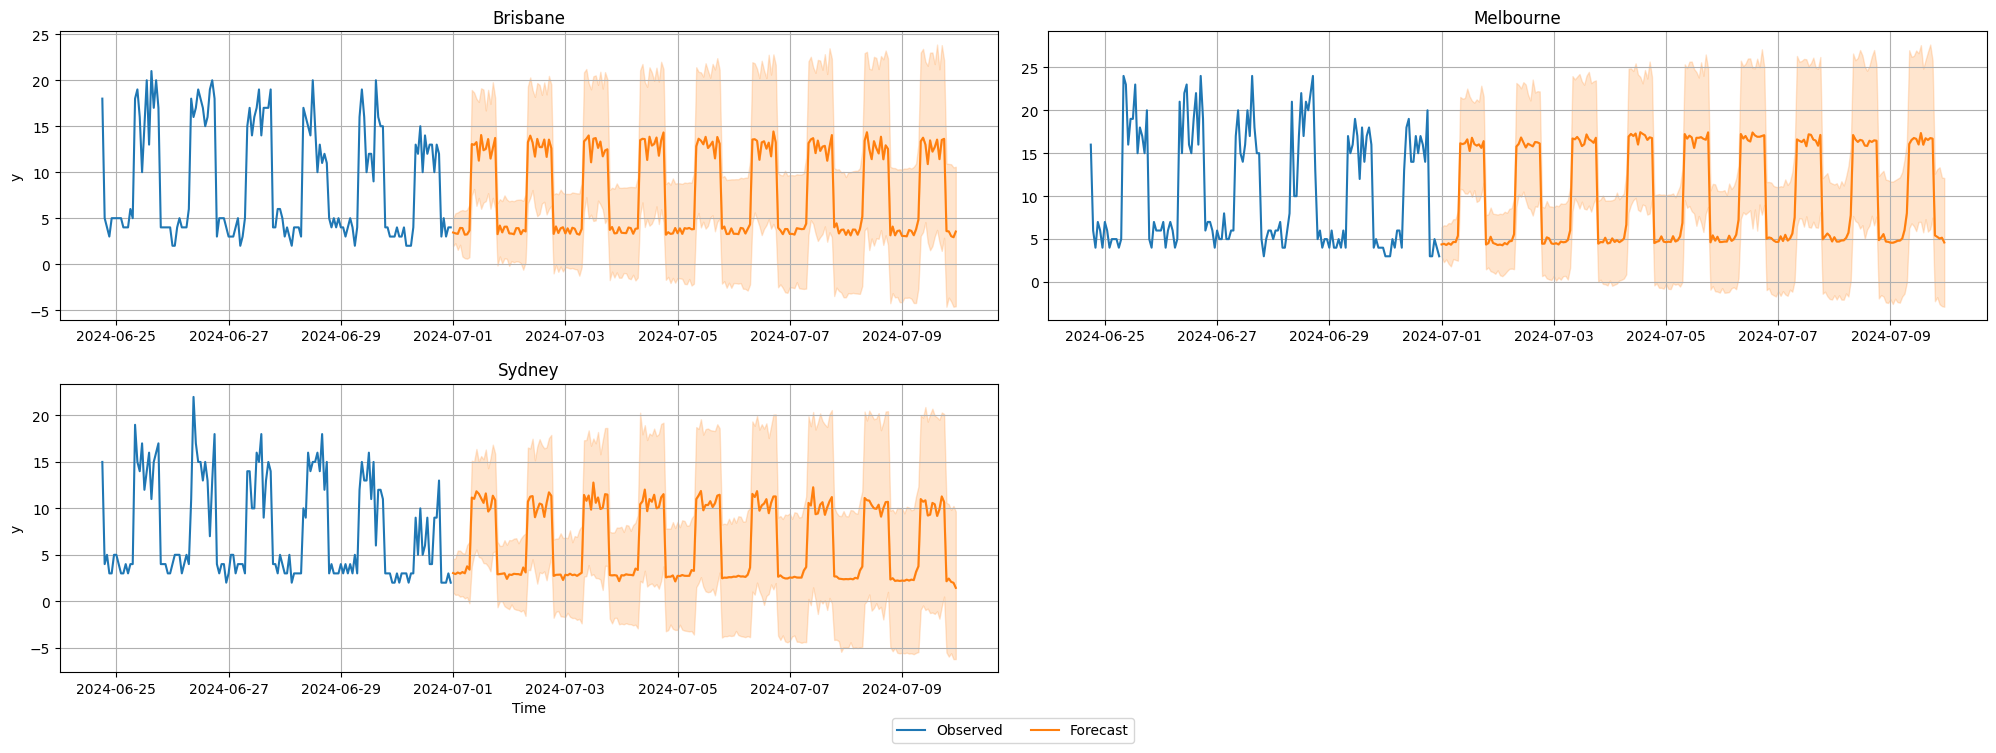

In [12]:
predictor.plot(timeseries_df, predictions, max_history_length = 150);

Future Covariates 

In [13]:
future_covariates = pd.read_csv("australia_library_future.csv")
future_covariates.head()

,datetime,location_name,day_of_week,event_day
0,2024-07-01 00:00:00,Sydney,0,0
1,2024-07-01 01:00:00,Sydney,0,0
2,2024-07-01 02:00:00,Sydney,0,0
3,2024-07-01 03:00:00,Sydney,0,0
4,2024-07-01 04:00:00,Sydney,0,0


In [14]:
future_timeseries_df = TimeSeriesDataFrame.from_data_frame(
    future_covariates,
    id_column = 'location_name',
    timestamp_column = 'datetime'
    )

In [15]:
predictor2 = TimeSeriesPredictor(
    prediction_length = prediction_length,
    target = 'y',
    eval_metric = 'RMSE',
    freq = "h",
    known_covariates_names = ['event_day', 'day_of_week']
)

In [ ]:
# Train the model using the covariates
predictor2.fit(
    timeseries_df,
    presets = 'best_quality',
    val_step_size = 96,
    random_seed = 42,
    num_val_windows = 50,
    time_limit = 600
)

Beginning AutoGluon training... Time limit = 300s
AutoGluon will save models to '/home/salgado/scripts/time_series/autogluon/AutogluonModels/ag-20250317_014933'
=================== System Info ===================
AutoGluon Version:  1.2
Python Version:     3.12.9
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP PREEMPT_DYNAMIC Thu Feb 27 15:07:31 UTC 2025
CPU Count:          16
GPU Count:          1
Memory Avail:       21.51 GB / 31.22 GB (68.9%)
Disk Space Avail:   163.16 GB / 235.84 GB (69.2%)
Setting presets to: best_quality

Fitting with arguments:
{'enable_ensemble': True,
 'eval_metric': RMSE,
 'freq': 'h',
 'hyperparameters': 'default',
 'known_covariates_names': ['event_day', 'day_of_week'],
 'num_val_windows': 50,
 'prediction_length': 216,
 'quantile_levels': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
 'random_seed': 42,
 'refit_every_n_windows': 1,
 'refit_full': False,
 'skip_model_selection': False,
 'target': 'y',
 'time_limit': 300,
 'v

In [17]:
predictor2.leaderboard(silent = True)

,model,score_val,pred_time_val,fit_time_marginal,fit_order
0,WeightedEnsemble,-3.297344,1.395225,1.857262,11
1,NPTS,-3.641608,0.515710,0.825797,3
2,ChronosZeroShot[bolt_base],-3.796976,1.163158,2.590934,5
3,DeepAR,-3.987414,0.623646,44.060885,8
4,SeasonalNaive,-4.155233,0.021809,0.071297,1
5,DirectTabular,-4.194001,0.050321,1.537251,2
6,ChronosFineTuned[bolt_small],-5.264034,0.061163,43.010646,6
7,TemporalFusionTransformer,-5.578682,0.028043,43.668664,7
8,PatchTST,-6.109422,0.030529,36.666988,9
9,AutoETS,-6.207156,0.183739,1.099322,4


In [18]:
future_timeseries_df

day_of_week  event_day
item_id  timestamp                                  
Sydney   2024-07-01 00:00:00            0          0
         2024-07-01 01:00:00            0          0
         2024-07-01 02:00:00            0          0
         2024-07-01 03:00:00            0          0
         2024-07-01 04:00:00            0          0
...                                   ...        ...
Brisbane 2024-07-09 19:00:00            1          1
         2024-07-09 20:00:00            1          1
         2024-07-09 21:00:00            1          1
         2024-07-09 22:00:00            1          1
         2024-07-09 23:00:00            1          1

[648 rows x 2 columns]

In [19]:
predictions2 = predictor2.predict(
    timeseries_df,
    random_seed = 42,
    known_covariates = future_timeseries_df)
predictions2.head()

Model not specified in predict, will default to the model with the best validation score: WeightedEnsemble


mean       0.1       0.2       0.3       0.4  \
item_id timestamp                                                               
Sydney  2024-07-01 00:00:00  2.827054  0.439566  1.361061  2.151836  2.467352   
        2024-07-01 01:00:00  2.596689  0.029163  1.080205  1.520801  2.301811   
        2024-07-01 02:00:00  2.790789 -0.018174  1.112672  1.630891  2.057189   
        2024-07-01 03:00:00  2.641591 -0.337286  0.860424  1.418557  2.313724   
        2024-07-01 04:00:00  2.872668 -0.384496  0.461423  1.878287  2.398166   

                                  0.5       0.6       0.7       0.8       0.9  
item_id timestamp                                                              
Sydney  2024-07-01 00:00:00  2.753560  3.450279  3.762262  4.124008  5.039485  
        2024-07-01 01:00:00  2.654801  3.014029  3.408535  4.259898  4.877844  
        2024-07-01 02:00:00  2.876066  3.282226  3.725564  4.630656  5.736042  
        2024-07-01 03:00:00  2.761186  3.199876  3.688665  4.242196  5.032983  
        2024-07-01 04:00:00  2.887912  3.368414  4.286376  4.889656  5.759963

In [20]:
predictor2.plot(timeseries_df, predictions2, max_history_length = 150);

Interpretability

In [21]:
feature_importance = predictor2.feature_importance(
    timeseries_df
)

Computing feature importance
Subsample_size 50 is larger than the number of items in the data and will be ignored


In [22]:
feature_importance

,importance,stdev,n,p99_low,p99_high
event_day,-0.005114,0.009119,5.0,-0.023891,0.013662
day_of_week,0.002517,0.016827,5.0,-0.032130,0.037164
temperature,0.000000,0.000000,0.0,NaN,NaN
rainfall,0.000000,0.000000,0.0,NaN,NaN


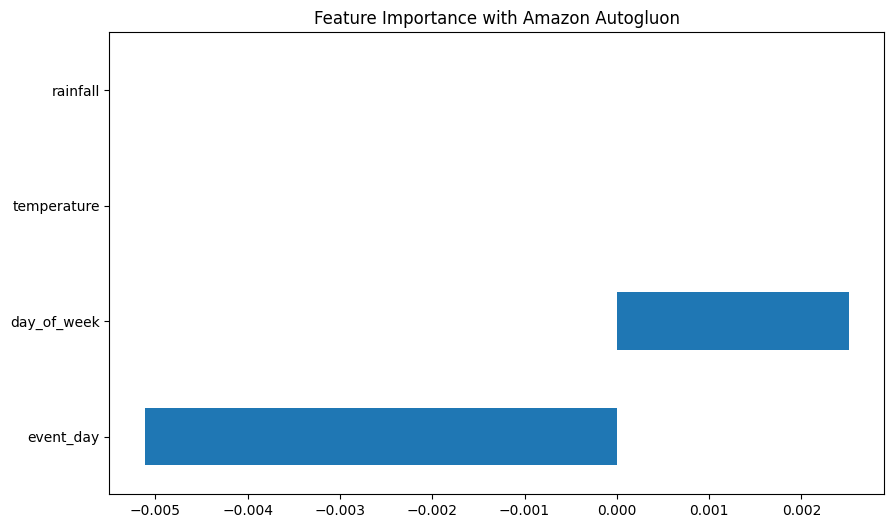

In [24]:
feature_importance.importance.plot(kind = 'barh', figsize = (10, 6))
plt.title("Feature Importance with Amazon Autogluon")
plt.show();